**Impostazione metodologica:** Si applicano gli algoritmi alle variabili
meteorologiche e si analizza **a posteriori** che cosa rappresentano i gruppi emersi.

Il **clustering** raggruppa i giorni per somiglianza delle condizioni meteo, e solo dopo si interpretano i cluster.

**Pipeline dell'analisi**
1. Preparazione dati e selezione delle feature
2. Scaling (obbligatorio)
3. PCA (riduzione dimensionalità e visualizzazione)
4. K-Means: confronto di tutti i k con cinque criteri, poi **validazione della scelta di k**
5. DBSCAN (eps con k-distance plot)
6. Confronto della qualità dei cluster (Silhouette, Davies-Bouldin, Calinski-Harabasz)
7. **Analisi a posteriori**: caratterizzazione e interpretazione dei cluster
8. Validazione incrociata con variabili NON usate nel clustering

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score,
                             adjusted_rand_score, v_measure_score)
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Caricamento e preparazione dei dati

In [3]:
import os
csv_path = "dataset/weatherAUS.csv" if os.path.exists("dataset/weatherAUS.csv") else "weatherAUS.csv"
df = pd.read_csv(csv_path, parse_dates=["Date"], na_values="NA")

# scarto le colonne con mancanti strutturali
df = df.drop(columns=["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"])

# variabili meteo numeriche e continue utilizzate 
features = ["MinTemp", "MaxTemp", "Rainfall", "WindGustSpeed",
            "WindSpeed9am", "WindSpeed3pm", "Humidity9am", "Humidity3pm",
            "Pressure9am", "Pressure3pm", "Temp9am", "Temp3pm"]

# tengo solo le righe complete su queste feature 
df = df.dropna(subset=features).copy()
df["Month"] = df["Date"].dt.month

print("Righe reali disponibili:", len(df))
print("Localita' rappresentate:", df["Location"].nunique())
print("Feature usate per il clustering:", len(features))

Righe reali disponibili: 120381
Localita' rappresentate: 44
Feature usate per il clustering: 12


### Sottocampionamento 

In [4]:
N_SAMPLE = 10000   # campione per il clustering 

df_s = df.sample(n=min(N_SAMPLE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

X = df_s[features] # SOLO variabili meteo numeriche
meta = df_s[["Location", "Month", "RainToday", "RainTomorrow"]] 

print("Campione usato:", X.shape)
X.describe().T[["mean", "std", "min", "50%", "max"]].round(1)

Campione usato: (10000, 12)


,mean,std,min,50%,max
MinTemp,12.4,6.4,-5.9,12.1,31.9
MaxTemp,23.5,7.0,6.3,23.0,47.0
Rainfall,2.4,8.5,0.0,0.0,206.2
WindGustSpeed,40.1,13.6,6.0,39.0,122.0
WindSpeed9am,14.3,8.8,0.0,13.0,63.0
WindSpeed3pm,19.1,8.8,0.0,19.0,87.0
Humidity9am,68.4,19.0,5.0,69.0,100.0
Humidity3pm,50.9,21.0,0.0,51.0,100.0
Pressure9am,1017.6,7.0,987.2,1017.5,1040.4
Pressure3pm,1015.2,7.0,982.2,1015.2,1037.7


## Scaling 

In [5]:
X = df_s[features].copy()
X["Rainfall"] = np.log1p(X["Rainfall"]) # log1p comprime la coda mantenendo l'ordine (log1p(0) = 0, quindi gli zeri restano zeri)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dopo lo scaling -> media = 0, deviazione = 1:")
print(pd.DataFrame(X_scaled, columns=features).describe().T[["mean", "std", "max"]].round(2).to_string())

Dopo lo scaling -> media = 0, deviazione = 1:
               mean  std   max
MinTemp        -0.0  1.0  3.07
MaxTemp         0.0  1.0  3.36
Rainfall       -0.0  1.0  5.34
WindGustSpeed  -0.0  1.0  6.02
WindSpeed9am   -0.0  1.0  5.54
WindSpeed3pm   -0.0  1.0  7.75
Humidity9am     0.0  1.0  1.66
Humidity3pm    -0.0  1.0  2.34
Pressure9am     0.0  1.0  3.24
Pressure3pm    -0.0  1.0  3.23
Temp9am        -0.0  1.0  3.47
Temp3pm        -0.0  1.0  3.33


## PCA

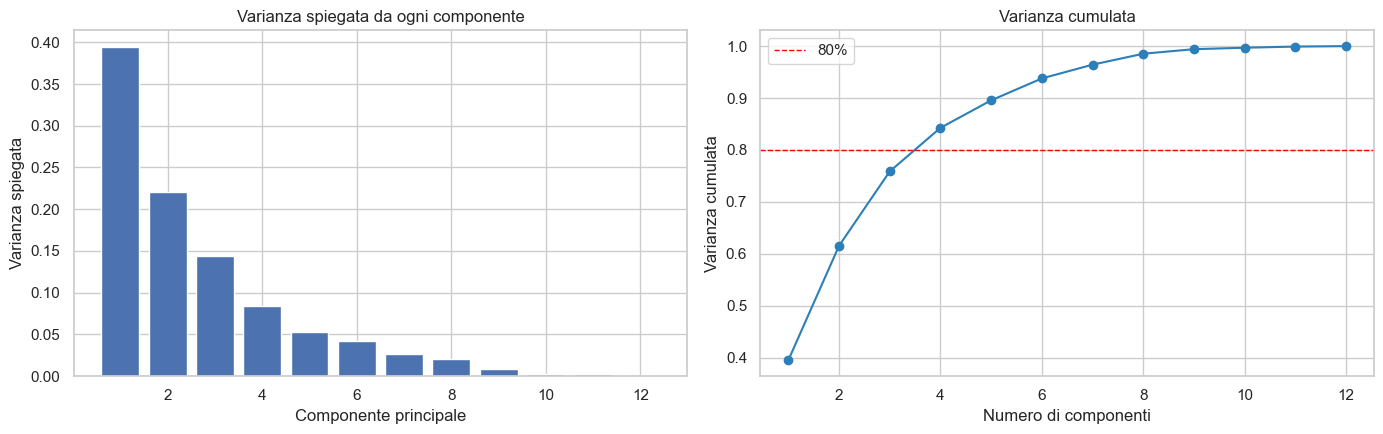

Varianza spiegata dalle prime 2 componenti: 61.5 %
Componenti necessarie per l'80%: 4


In [6]:
pca_full = PCA().fit(X_scaled)

# calcolo la varianza spiegata da ogni componente 
var_ratio = pca_full.explained_variance_ratio_
# calcolo la varianza cumulata
cum_var = var_ratio.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(range(1, len(var_ratio) + 1), var_ratio, color="#4C72B0")
axes[0].set_xlabel("Componente principale"); axes[0].set_ylabel("Varianza spiegata")
axes[0].set_title("Varianza spiegata da ogni componente")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#2C7FB8")
axes[1].axhline(0.80, color="red", ls="--", lw=1, label="80%")
axes[1].set_xlabel("Numero di componenti"); axes[1].set_ylabel("Varianza cumulata")
axes[1].set_title("Varianza cumulata"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Varianza spiegata dalle prime 2 componenti:", round(cum_var[1]*100, 1), "%")
print("Componenti necessarie per l'80%:", int(np.argmax(cum_var >= 0.80)) + 1)

In [7]:
# Proiezione 2D usata per tutte le visualizzazioni successive
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_scaled)

# Quali variabili "pesano" su PC1 e PC2 
loadings = pd.DataFrame(pca2.components_.T, index=features, columns=["PC1", "PC2"])
print("Contributi delle variabili alle prime 2 componenti:")
print(loadings.round(2).to_string())

Contributi delle variabili alle prime 2 componenti:
                PC1   PC2
MinTemp        0.37  0.04
MaxTemp        0.41 -0.23
Rainfall      -0.04  0.36
WindGustSpeed  0.19  0.41
WindSpeed9am   0.14  0.32
WindSpeed3pm   0.15  0.37
Humidity9am   -0.28  0.21
Humidity3pm   -0.19  0.34
Pressure9am   -0.29 -0.32
Pressure3pm   -0.31 -0.26
Temp9am        0.41 -0.09
Temp3pm        0.40 -0.26


## K-Means 
K-Means richiede di fissare **k** in anticipo. Due criteri complementari:
- **Elbow method**: la somma delle distanze dai centroidi cala sempre all'aumentare di k; si cerca
  il "gomito", il punto oltre il quale il guadagno diventa marginale.
- **Silhouette score**: misura quanto ogni punto è vicino al proprio cluster rispetto agli altri
  (da -1 a 1, più alto è meglio). Ha un massimo, quindi è più oggettivo dell'elbow.

In [8]:
ks = range(2, 9)

# Converte il mese nella stagione corrispondente
stagione = (df_s["Month"] % 12 // 3).map({0: "Estate", 1: "Autunno",
                                          2: "Inverno", 3: "Primavera"})   
mask_stag = pd.notna(stagione).values
stag_v = np.asarray(stagione)[mask_stag]

righe = []
for k in ks:
    km  = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lab = km.fit_predict(X_scaled)
    
    # Calcolo della silhouette su un sotto-campione casuale per velocizzare il calcolo O(n^2)
    sil = silhouette_score(X_scaled, lab, sample_size=5000, random_state=RANDOM_STATE)
    righe.append({
        "k": k,
        "Inerzia":           km.inertia_,  # errore quadratico medio (elbow)
        "Silhouette":        sil,          #Coesione vs Separazione (più alto è meglio)
        "Davies-Bouldin":    davies_bouldin_score(X_scaled, lab), # Rapporto dispersione/distanza
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, lab), # Varianza inter-cluster vs intra-cluster
        "ARI vs stagione":   adjusted_rand_score(stag_v, lab[mask_stag]), # Somiglianza con le stagioni (0 = casuale, 1 = coincidenza)
        "V-measure":         v_measure_score(stag_v, lab[mask_stag]), # Omogeneità e completezza rispetto alle stagioni
    })
    print(f"k={k}: inerzia={km.inertia_:,.0f}  silhouette={sil:.3f}")

df_metriche = pd.DataFrame(righe).set_index("k")

# k preferito da ciascun criterio 
regola = {"Silhouette": "idxmax", 
          "Davies-Bouldin": "idxmin", 
          "Calinski-Harabasz": "idxmax",
          "ARI vs stagione": "idxmax",
          "V-measure": "idxmax"}
print("\nk preferito da ciascun criterio:")
for col, how in regola.items():
    # Estraiamo dinamicamente l'indice k ottimale usando idxmax o idxmin
    print(f"  {col:20s}-> k={getattr(df_metriche[col], how)()}")

best_k_sil = df_metriche["Silhouette"].idxmax()   # usato nei grafici come riferimento
df_metriche.round(3)

k=2: inerzia=88,685  silhouette=0.230
k=3: inerzia=74,788  silhouette=0.226
k=4: inerzia=67,897  silhouette=0.161
k=5: inerzia=62,527  silhouette=0.160
k=6: inerzia=58,368  silhouette=0.162
k=7: inerzia=55,531  silhouette=0.159
k=8: inerzia=53,080  silhouette=0.152

k preferito da ciascun criterio:
  Silhouette          -> k=2
  Davies-Bouldin      -> k=3
  Calinski-Harabasz   -> k=2
  ARI vs stagione     -> k=2
  V-measure           -> k=2


,Inerzia,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI vs stagione,V-measure
k,,,,,,
2,88684.795,0.230,1.591,3530.365,0.120,0.129
3,74788.114,0.226,1.572,3021.760,0.097,0.098
4,67897.272,0.161,1.648,2556.899,0.093,0.114
5,62526.970,0.160,1.599,2296.782,0.087,0.115
6,58367.689,0.162,1.654,2110.600,0.079,0.104
7,55530.624,0.159,1.619,1933.595,0.078,0.109
8,53079.810,0.152,1.610,1799.631,0.069,0.103


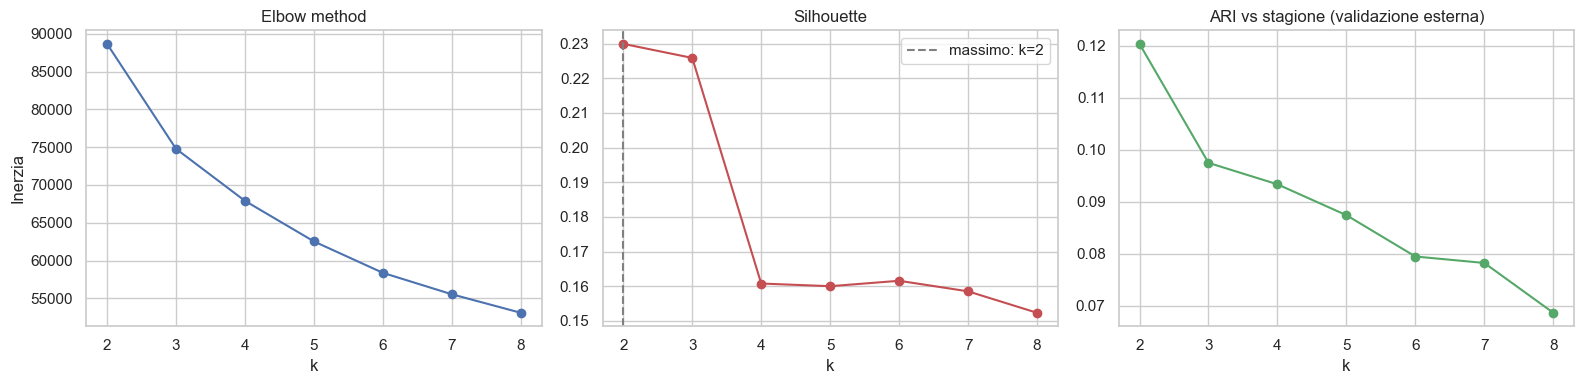

Silhouette massima suggerita dai dati: 2


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df_metriche.index, df_metriche["Inerzia"], marker="o", color="#4C72B0")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inerzia")

axes[1].plot(df_metriche.index, df_metriche["Silhouette"], marker="o", color="#C44E52")
axes[1].axvline(best_k_sil, color="gray", ls="--", label=f"massimo: k={best_k_sil}")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(df_metriche.index, df_metriche["ARI vs stagione"], marker="o", color="#55A868")
axes[2].set_title("ARI vs stagione (validazione esterna)")
axes[2].set_xlabel("k")

plt.tight_layout(); 
plt.show()

print("Silhouette massima suggerita dai dati:", best_k_sil)

### Validazione della scelta di k

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
inerzia_tot = KMeans(n_clusters=1, n_init=10, random_state=RANDOM_STATE).fit(X_scaled).inertia_

righe_val = []
for k in [2, 3, 4, 5]:
    km  = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    lab = km.labels_

    # (a) la partizione si riproduce tagliando UNA sola variabile? (tengo la piu' somigliante)
    riducibilita = max(
        adjusted_rand_score(lab, pd.qcut(X[f], k, labels=False, duplicates="drop"))
        for f in features)

    # (b) stabilita': ri-clusterizzo l'80% dei dati e confronto con la partizione originale
    stab = []
    for b in range(10):
        sub = rng.choice(len(X_scaled), int(0.8 * len(X_scaled)), replace=False)
        lab_b = KMeans(n_clusters=k, n_init=10, random_state=b).fit_predict(X_scaled[sub])
        stab.append(adjusted_rand_score(km.predict(X_scaled[sub]), lab_b))

    righe_val.append({
        "k": k,
        "Varianza spiegata":      1 - km.inertia_ / inerzia_tot,
        "Stabilita' (ARI)":       np.mean(stab),
        "Dev.std stabilita'":     np.std(stab),
        "Riducibilita' a 1 var.": riducibilita,
        "Dist. min centroidi":    pdist(km.cluster_centers_).min(),
    })

df_val = pd.DataFrame(righe_val).set_index("k").round(3)
print("Validazione della scelta di k:\n")
df_val

Validazione della scelta di k:



,Varianza spiegata,Stabilita' (ARI),Dev.std stabilita',Riducibilita' a 1 var.,Dist. min centroidi
k,,,,,
2,0.261,0.993,0.004,0.522,3.545
3,0.377,0.985,0.005,0.347,3.454
4,0.434,0.980,0.006,0.337,2.746
5,0.479,0.865,0.161,0.251,2.675


### K-Means finale 

In [11]:
# Scelta documentata
K = 4

print(f"Silhouette massima suggerita dai dati: {best_k_sil}  |  k adottato: {K}")

kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)
df_s["cluster_km"] = labels_km

print("\nNumerosita' dei cluster K-Means:")
print(pd.Series(labels_km).value_counts().sort_index().to_string())

Silhouette massima suggerita dai dati: 2  |  k adottato: 4

Numerosita' dei cluster K-Means:
0    2427
1    3239
2    2409
3    1925


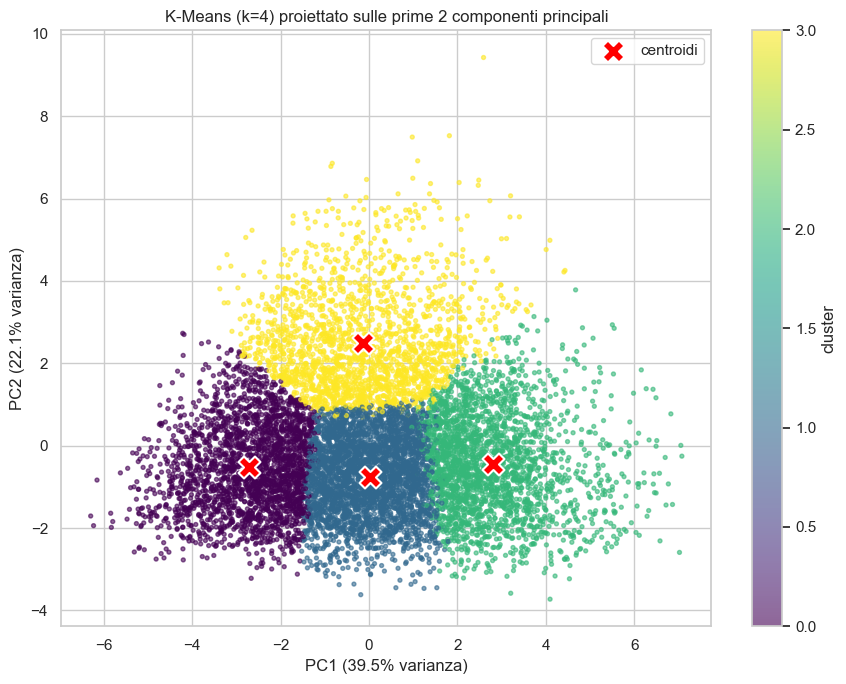

In [12]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="viridis", s=8, alpha=0.6)
centroids_pca = pca2.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="red", marker="X", s=250,
            edgecolor="white", linewidth=1.5, label="centroidi")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title(f"K-Means (k={K}) proiettato sulle prime 2 componenti principali")
plt.colorbar(scatter, label="cluster"); plt.legend()
plt.tight_layout(); plt.show()

## DBSCAN 

Richiede due parametri:
- `min_samples`: punti minimi per formare una zona densa (regola pratica: ~2 × n. dimensioni).
- `eps`: il raggio di vicinato. Si tara con il **k-distance plot**: si ordina la distanza di ogni punto dal
  suo k-esimo vicino e si cerca il "ginocchio" della curva.

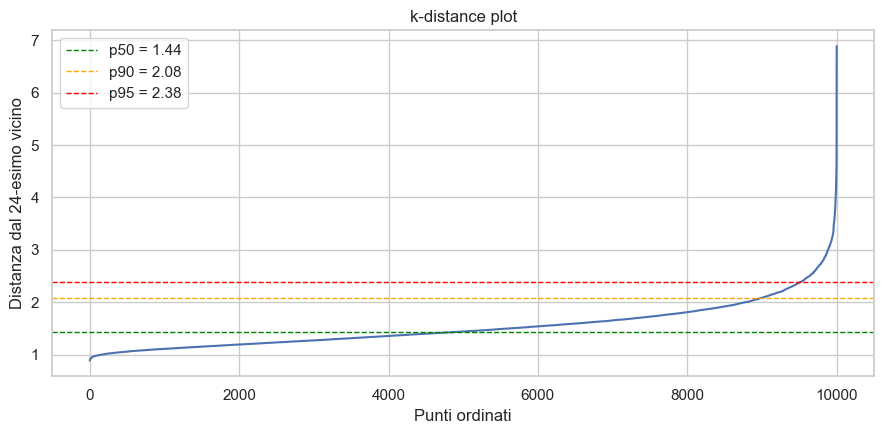

min_samples = 24
La curva non ha un ginocchio netto -> testo una griglia di valori invece di sceglierne uno a caso.


In [13]:
min_samples = 2 * X_scaled.shape[1]   # regola pratica: 2 x numero di feature

nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4.5))
plt.plot(k_dist, color="#4C72B0")
plt.xlabel("Punti ordinati"); plt.ylabel(f"Distanza dal {min_samples}-esimo vicino")
plt.title("k-distance plot")
for p, col in [(50, "green"), (90, "orange"), (95, "red")]:
    v = np.percentile(k_dist, p)
    plt.axhline(v, color=col, ls="--", lw=1, label=f"p{p} = {v:.2f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"min_samples = {min_samples}")
print("La curva non ha un ginocchio netto -> testo una griglia di valori invece di sceglierne uno a caso.")

In [14]:
righe = []
for eps_try in [1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]:
    lab = DBSCAN(eps=eps_try, min_samples=min_samples, n_jobs=-1).fit_predict(X_scaled)
    n_c = len(set(lab)) - (1 if -1 in lab else 0)
    n_o = int((lab == -1).sum())
    dim_max = pd.Series(lab[lab != -1]).value_counts().max() if n_c > 0 else 0
    righe.append({"eps": eps_try, "n_cluster": n_c, "outlier": n_o,
                  "% outlier": round(n_o / len(lab) * 100, 1),
                  "dim. cluster piu' grande": dim_max})
griglia = pd.DataFrame(righe)
print(griglia.to_string(index=False))

 eps  n_cluster  outlier  % outlier  dim. cluster piu' grande
 1.0          3     8752       87.5                      1194
 1.2          1     5073       50.7                      4927
 1.5          1     1953       19.5                      8047
 1.8          1      636        6.4                      9364
 2.0          1      343        3.4                      9657
 2.5          1       57        0.6                      9943
 3.0          1       11        0.1                      9989


In [15]:
EPS = 1.5   
dbscan = DBSCAN(eps=EPS, min_samples=min_samples)
labels_db = dbscan.fit_predict(X_scaled)
df_s["cluster_db"] = labels_db

n_cluster_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_outlier = int((labels_db == -1).sum())
print(f"DBSCAN -> cluster trovati: {n_cluster_db} | outlier: {n_outlier} ({n_outlier/len(labels_db)*100:.1f}%)")
print(pd.Series(labels_db).value_counts().sort_index().to_string())

DBSCAN -> cluster trovati: 1 | outlier: 1953 (19.5%)
-1    1953
 0    8047


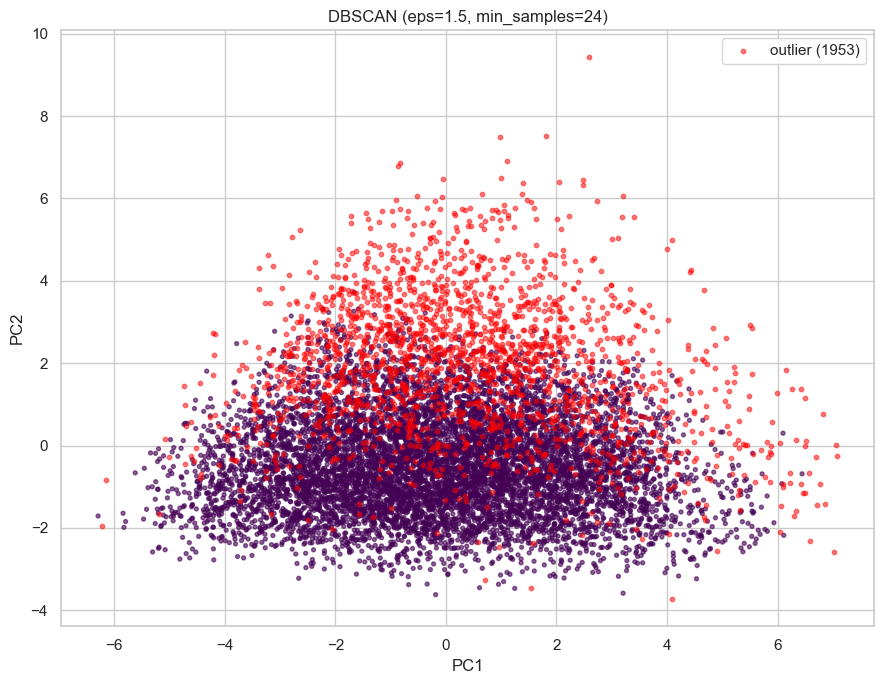

In [16]:
plt.figure(figsize=(9, 7))
mask = labels_db == -1
plt.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c=labels_db[~mask], cmap="viridis", s=8, alpha=0.6)
plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c="red", s=10, alpha=0.5, label=f"outlier ({n_outlier})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"DBSCAN (eps={EPS}, min_samples={min_samples})")
plt.legend(); plt.tight_layout(); plt.show()

### Visualizzazione con t-SNE

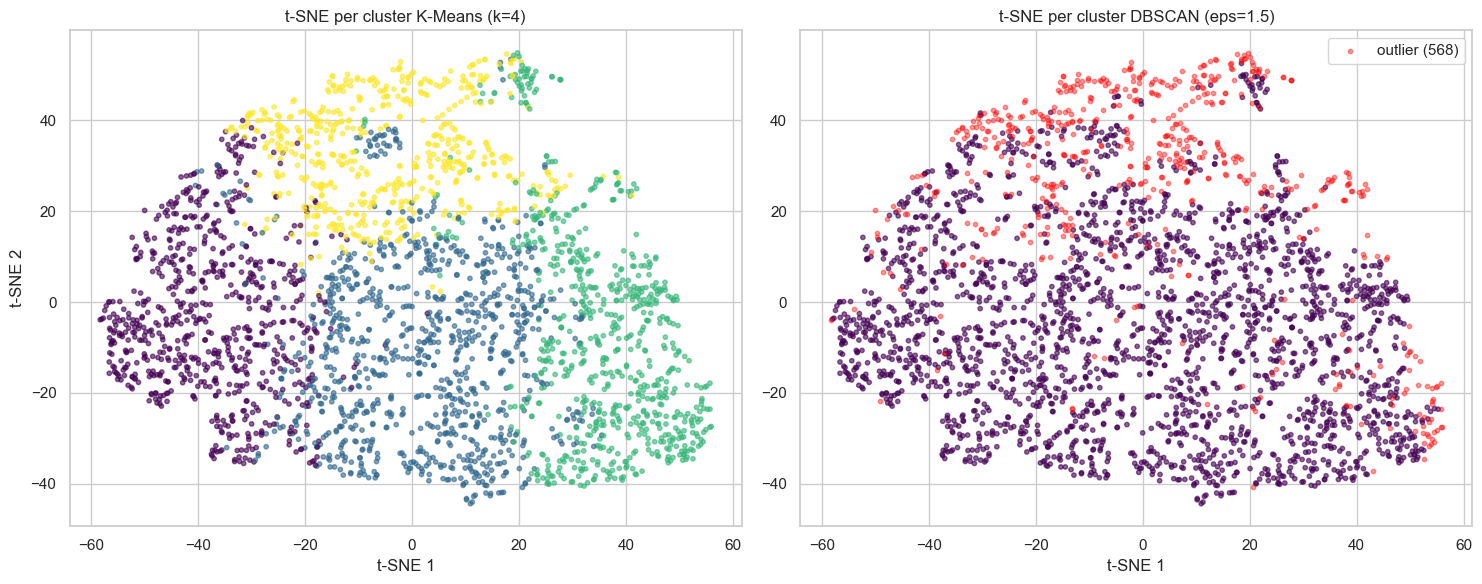

In [17]:
from sklearn.manifold import TSNE

# Calcolo t-SNE su un sottocampione di 3000 punti
tsne_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=3000, replace=False)
X_tsne = TSNE(n_components=2, init="pca", perplexity=30,
              random_state=RANDOM_STATE).fit_transform(X_scaled[tsne_idx])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) colorato per cluster K-Means
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km[tsne_idx],
                cmap="viridis", s=10, alpha=.6)
axes[0].set_title(f"t-SNE per cluster K-Means (k={K})")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

# (b) colorato per cluster DBSCAN (outlier in rosso)
db_sub = labels_db[tsne_idx]
mask = db_sub == -1
axes[1].scatter(X_tsne[~mask, 0], X_tsne[~mask, 1], c=db_sub[~mask], cmap="viridis", s=10, alpha=.6)
axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c="red", s=10, alpha=.4,
                label=f"outlier ({int(mask.sum())})")
axes[1].set_title(f"t-SNE per cluster DBSCAN (eps={EPS})")
axes[1].set_xlabel("t-SNE 1"); axes[1].legend()
plt.tight_layout(); plt.show()

## Confronto della qualità dei cluster

In [18]:
def valuta(X_, labels_):
    mask = labels_ != -1                      # escludo eventuali outlier DBSCAN
    Xv, lv = X_[mask], labels_[mask]
    if len(set(lv)) < 2:
        return {"Silhouette": np.nan, "Davies-Bouldin": np.nan,
                "Calinski-Harabasz": np.nan, "N. cluster": len(set(lv))}
    return {
        "Silhouette":        silhouette_score(Xv, lv, sample_size=5000, random_state=RANDOM_STATE),
        "Davies-Bouldin":    davies_bouldin_score(Xv, lv),
        "Calinski-Harabasz": calinski_harabasz_score(Xv, lv),
        "N. cluster":        len(set(lv)),
    }

confronto = {
    f"K-Means (k={K})":     valuta(X_scaled, labels_km),
    f"DBSCAN (eps={EPS})":  valuta(X_scaled, labels_db),
}
pd.DataFrame(confronto).T.round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,N. cluster
K-Means (k=4),0.161,1.648,2556.899,4.0
DBSCAN (eps=1.5),NaN,NaN,NaN,1.0


## Analisi a posteriori

In [19]:
# profilo dei cluster in unita' originali (interpretabile fisicamente)
profilo = df_s.groupby("cluster_km")[features].mean().round(1)
profilo["n_giorni"] = df_s["cluster_km"].value_counts().sort_index()
print("Valori medi per cluster (unita' originali):")
profilo

Valori medi per cluster (unita' originali):


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,n_giorni
cluster_km,,,,,,,,,,,,,
0,6.0,16.8,1.3,30.4,9.3,14.0,82.0,58.1,1024.3,1022.0,10.3,15.8,2427
1,12.2,24.4,0.4,36.1,12.5,17.1,63.4,45.1,1019.3,1016.6,17.6,23.0,3239
2,19.3,32.5,1.2,43.8,15.9,21.0,54.5,39.0,1012.8,1009.7,25.2,30.7,2409
3,12.2,19.1,8.6,54.4,21.6,26.3,77.1,66.6,1012.1,1010.9,15.1,17.3,1925


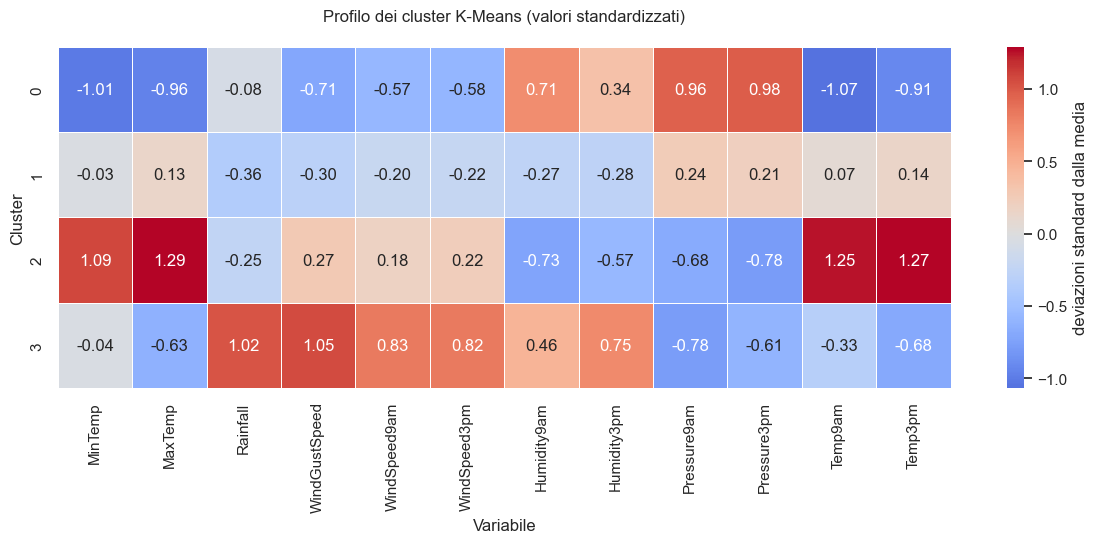

In [20]:
# profilo standardizzato: quanto ogni cluster si discosta dalla media generale
profilo_std = pd.DataFrame(X_scaled, columns=features).groupby(labels_km).mean()

plt.figure(figsize=(12, 4 + 0.4 * K))
sns.heatmap(profilo_std, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=.5, cbar_kws={"label": "deviazioni standard dalla media"})
plt.title("Profilo dei cluster K-Means (valori standardizzati)\n")
plt.xlabel("Variabile"); plt.ylabel("Cluster")
plt.tight_layout(); plt.show()

In [21]:
# etichetta interpretativa automatica: le 2 variabili piu' caratterizzanti di ogni cluster
print("Tratti distintivi di ciascun cluster (scostamento dalla media):\n")
for c in sorted(profilo_std.index):
    riga = profilo_std.loc[c]
    top = riga.abs().sort_values(ascending=False).head(3).index
    tratti = [f"{v} {'ALTO' if riga[v] > 0 else 'BASSO'} ({riga[v]:+.2f})" for v in top]
    print(f"Cluster {c} ({profilo.loc[c, 'n_giorni']} giorni): " + " | ".join(tratti))

Tratti distintivi di ciascun cluster (scostamento dalla media):

Cluster 0 (2427 giorni): Temp9am BASSO (-1.07) | MinTemp BASSO (-1.01) | Pressure3pm ALTO (+0.98)
Cluster 1 (3239 giorni): Rainfall BASSO (-0.36) | WindGustSpeed BASSO (-0.30) | Humidity3pm BASSO (-0.28)
Cluster 2 (2409 giorni): MaxTemp ALTO (+1.29) | Temp3pm ALTO (+1.27) | Temp9am ALTO (+1.25)
Cluster 3 (1925 giorni): WindGustSpeed ALTO (+1.05) | Rainfall ALTO (+1.02) | WindSpeed9am ALTO (+0.83)


## Validazione incrociata con variabili NON usate nel clustering

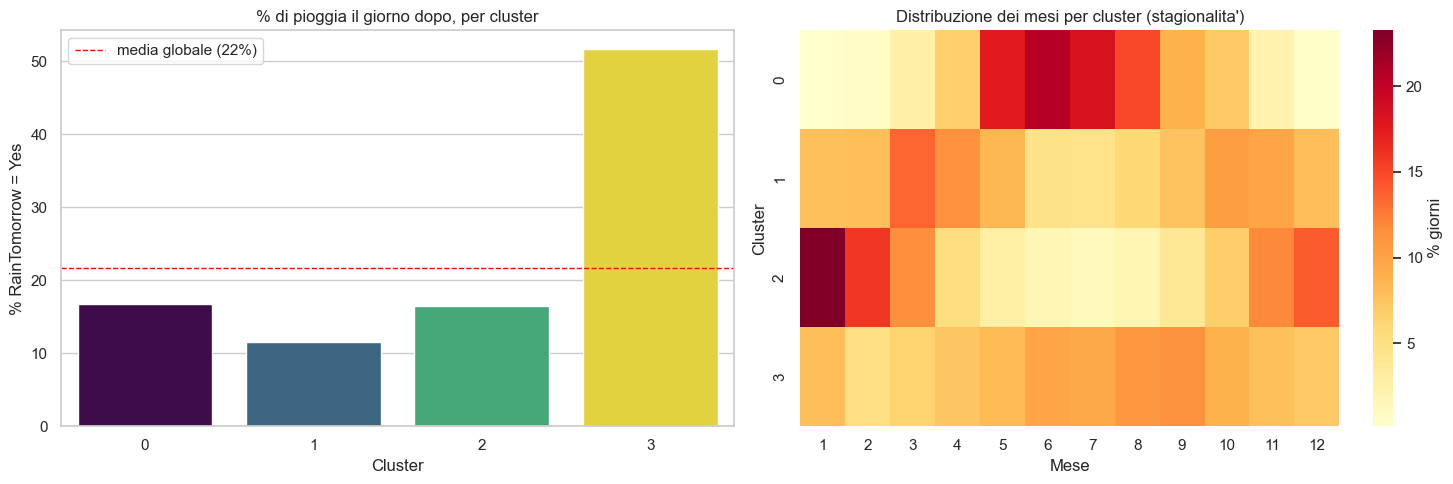

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) quanta pioggia il giorno dopo, per cluster
rain_by_cluster = df_s.groupby("cluster_km")["RainTomorrow"].apply(
    lambda s: (s == "Yes").mean() * 100)
sns.barplot(x=rain_by_cluster.index, y=rain_by_cluster.values,
            hue=rain_by_cluster.index, palette="viridis", legend=False, ax=axes[0])
media_glob = (df_s["RainTomorrow"] == "Yes").mean() * 100
axes[0].axhline(media_glob, color="red", ls="--", lw=1, label=f"media globale ({media_glob:.0f}%)")
axes[0].set_title("% di pioggia il giorno dopo, per cluster")
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("% RainTomorrow = Yes"); axes[0].legend()

# (b) distribuzione dei mesi per cluster
mesi = pd.crosstab(df_s["cluster_km"], df_s["Month"], normalize="index") * 100
sns.heatmap(mesi, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "% giorni"})
axes[1].set_title("Distribuzione dei mesi per cluster (stagionalita')")
axes[1].set_xlabel("Mese"); axes[1].set_ylabel("Cluster")

plt.tight_layout(); plt.show()

In [23]:
print("Localita' piu' rappresentate in ciascun cluster:\n")
for c in sorted(df_s["cluster_km"].unique()):
    top_loc = df_s[df_s["cluster_km"] == c]["Location"].value_counts(normalize=True).head(3)
    loc_str = ", ".join(f"{l} ({p*100:.0f}%)" for l, p in top_loc.items())
    print(f"Cluster {c}: {loc_str}")

Localita' piu' rappresentate in ciascun cluster:

Cluster 0: Watsonia (4%), Ballarat (4%), Albury (4%)
Cluster 1: Brisbane (5%), NorfolkIsland (4%), Adelaide (3%)
Cluster 2: Darwin (11%), Cairns (8%), Townsville (6%)
Cluster 3: Ballarat (5%), NorfolkIsland (5%), Hobart (5%)


In [24]:
# (d) i cluster coincidono con la variabile RainToday? (tabella di contingenza)
ct = pd.crosstab(df_s["cluster_km"], df_s["RainToday"], normalize="index") * 100
print("\n% di giorni con pioggia OGGI, per cluster:")
print(ct.round(1).to_string())


% di giorni con pioggia OGGI, per cluster:
RainToday     No   Yes
cluster_km            
0           78.6  21.4
1           92.2   7.8
2           87.9  12.1
3           39.6  60.4


### Validazione quantitativa: quanto i cluster somigliano a etichette esterne

In [25]:
from sklearn.metrics import (adjusted_rand_score, v_measure_score,
                             homogeneity_score, completeness_score)

# etichette esterne NON usate nel clustering
stagione = (df_s["Month"] % 12 // 3).map({0: "Estate", 1: "Autunno",
                                          2: "Inverno", 3: "Primavera"})  # emisfero sud

def validazione_esterna(labels, y_ext):
    m = pd.notna(y_ext).values                      # escludo righe senza etichetta esterna
    yv, lv = np.asarray(y_ext)[m], np.asarray(labels)[m]
    return {"Adjusted Rand Index": adjusted_rand_score(yv, lv), 
            "V-measure":           v_measure_score(yv, lv), # media armonica di omogeneità e completezza (0–1)

            "Homogeneity":         homogeneity_score(yv, lv),
            "Completeness":        completeness_score(yv, lv)}

tab_ext = pd.DataFrame({
    "vs Stagione":       validazione_esterna(labels_km, stagione),
    "vs Pioggia domani": validazione_esterna(labels_km, df_s["RainTomorrow"]),
    "vs Localita'":      validazione_esterna(labels_km, df_s["Location"]),
}).T.round(3)
print("Corrispondenza dei cluster K-Means con etichette esterne (0 = casuale, 1 = perfetta):")
tab_ext

Corrispondenza dei cluster K-Means con etichette esterne (0 = casuale, 1 = perfetta):


,Adjusted Rand Index,V-measure,Homogeneity,Completeness
vs Stagione,0.093,0.114,0.113,0.114
vs Pioggia domani,0.055,0.061,0.110,0.042
vs Localita',0.014,0.068,0.047,0.128


### La validazione a posteriori sulla mappa

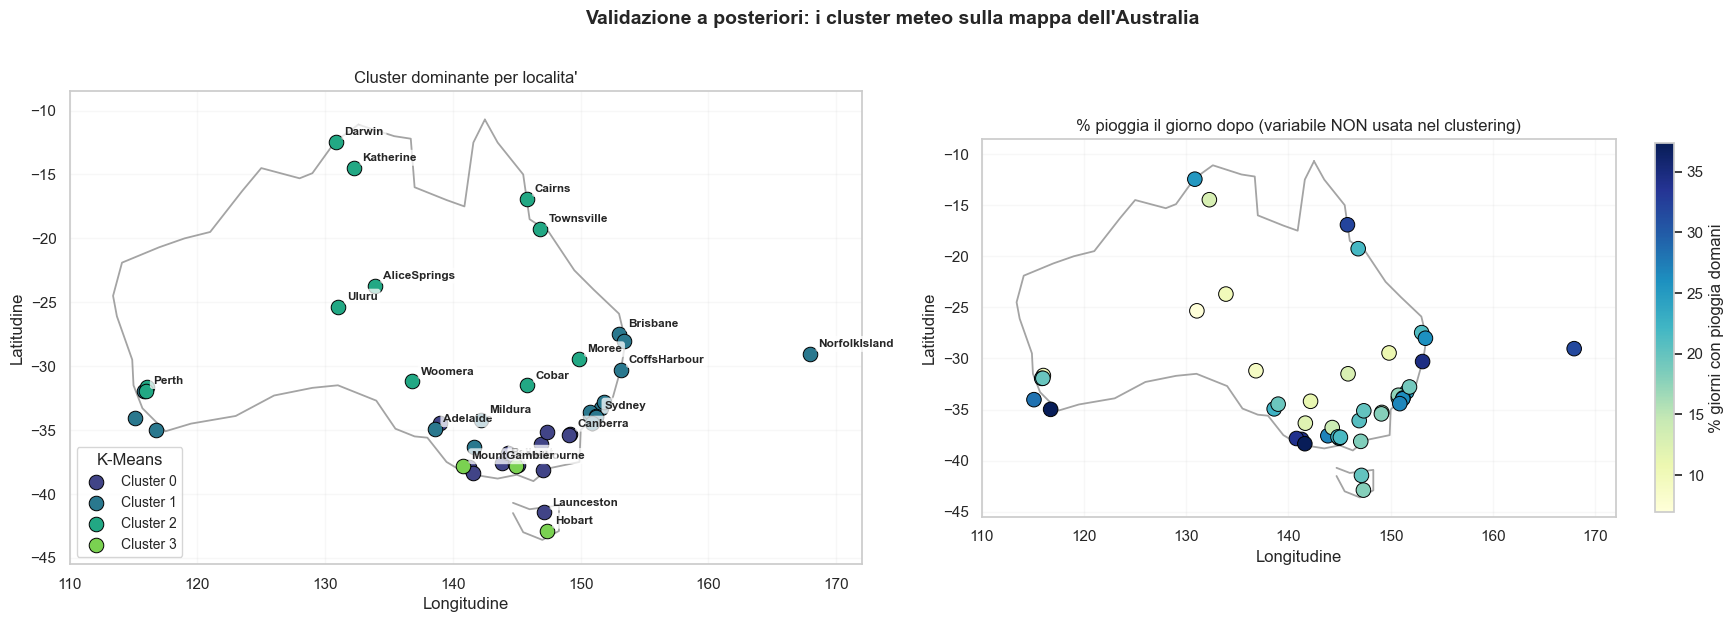

In [27]:
# Coordinate approssimate delle stazioni (non presenti nel dataset) e profilo schematico dell'Australia
COORDS = {
 "Albury":(-36.08,146.92),"BadgerysCreek":(-33.88,150.75),"Cobar":(-31.50,145.83),
 "CoffsHarbour":(-30.30,153.12),"Moree":(-29.46,149.84),"Newcastle":(-32.93,151.78),
 "NorahHead":(-33.28,151.57),"NorfolkIsland":(-29.04,167.95),"Penrith":(-33.75,150.69),
 "Richmond":(-33.60,150.75),"Sydney":(-33.87,151.21),"SydneyAirport":(-33.95,151.18),
 "WaggaWagga":(-35.12,147.37),"Williamtown":(-32.79,151.84),"Wollongong":(-34.42,150.89),
 "Canberra":(-35.28,149.13),"Tuggeranong":(-35.42,149.09),"MountGinini":(-35.53,148.77),
 "Ballarat":(-37.56,143.85),"Bendigo":(-36.76,144.28),"Sale":(-38.11,147.07),
 "MelbourneAirport":(-37.67,144.84),"Melbourne":(-37.81,144.96),"Mildura":(-34.19,142.16),
 "Nhil":(-36.33,141.65),"Portland":(-38.34,141.60),"Watsonia":(-37.71,145.08),
 "Dartmoor":(-37.92,141.28),"Brisbane":(-27.47,153.03),"Cairns":(-16.92,145.77),
 "GoldCoast":(-28.02,153.40),"Townsville":(-19.26,146.82),"Adelaide":(-34.93,138.60),
 "MountGambier":(-37.83,140.78),"Nuriootpa":(-34.47,138.99),"Woomera":(-31.20,136.82),
 "Albany":(-35.03,117.88),"Witchcliffe":(-34.03,115.10),"PearceRAAF":(-31.67,116.02),
 "PerthAirport":(-31.94,115.97),"Perth":(-31.95,115.86),"SalmonGums":(-32.98,121.64),
 "Walpole":(-34.98,116.73),"Hobart":(-42.88,147.33),"Launceston":(-41.44,147.14),
 "AliceSprings":(-23.70,133.88),"Darwin":(-12.46,130.84),"Katherine":(-14.47,132.26),
 "Uluru":(-25.34,131.04),
}
AUS = [(142.5,-10.7),(141.6,-12.5),(140.9,-17.5),(139.5,-17.0),(137.0,-16.0),(136.7,-12.2),
 (135.4,-12.0),(132.6,-11.1),(130.8,-12.4),(129.0,-14.9),(128.0,-15.3),(125.0,-14.5),
 (123.5,-16.3),(121.0,-19.5),(119.0,-20.0),(117.0,-20.7),(114.1,-21.9),(113.4,-24.5),
 (113.7,-26.1),(114.9,-29.5),(115.0,-31.5),(115.7,-33.3),(117.5,-35.1),(119.5,-34.5),
 (123.0,-33.9),(126.0,-32.3),(129.0,-31.7),(131.0,-31.5),(134.0,-32.7),(135.5,-34.9),
 (137.0,-35.5),(138.0,-35.6),(139.5,-37.5),(141.0,-38.4),(143.5,-38.8),(145.0,-38.5),
 (146.3,-39.0),(147.5,-38.0),(149.9,-37.5),(150.0,-35.0),(152.5,-32.5),(153.2,-30.0),
 (153.5,-28.0),(153.0,-25.9),(151.0,-24.0),(149.5,-22.5),(147.5,-19.5),(146.0,-18.5),
 (145.5,-15.0),(143.5,-12.5),(142.5,-10.7)]
TAS = [(144.7,-40.7),(146.0,-41.2),(148.3,-40.9),(148.3,-42.9),(147.0,-43.6),(145.5,-43.0),(144.7,-41.5)]

# Etichetto solo una localita' per zona climatica
ETICHETTE = {"Darwin","Katherine","Cairns","Townsville","AliceSprings","Uluru","Woomera",
             "Brisbane","CoffsHarbour","Sydney","Canberra","Cobar","Moree","NorfolkIsland",
             "Melbourne","Ballarat","Mildura","Hobart","Launceston","Adelaide","MountGambier",
             "Perth","Albany","SalmonGums"}

# cluster dominante e % pioggia per ogni localita'
geo = df_s.groupby("Location").agg(
    cluster_dom=("cluster_km", lambda s: s.value_counts().idxmax()),
    n_giorni=("cluster_km", "size"),
    pct_pioggia=("RainTomorrow", lambda s: (s == "Yes").mean() * 100)).reset_index()
geo["lat"] = geo["Location"].map(lambda l: COORDS.get(l, (np.nan, np.nan))[0])
geo["lon"] = geo["Location"].map(lambda l: COORDS.get(l, (np.nan, np.nan))[1])
geo = geo.dropna(subset=["lat", "lon"])

def base_map(ax):
    ax.plot(*zip(*AUS), color="#8d8d8d", lw=1.3, alpha=.8, zorder=1)
    ax.plot(*zip(*TAS), color="#8d8d8d", lw=1.3, alpha=.8, zorder=1)
    ax.set_xlim(110, 172); ax.set_ylim(-45.5, -8.5)
    ax.set_aspect("equal"); ax.grid(alpha=.15)
    ax.set_xlabel("Longitudine"); ax.set_ylabel("Latitudine")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax in axes:
    base_map(ax)

# (a) cluster dominante per localita'
pal = sns.color_palette("viridis", K)
for c in sorted(geo["cluster_dom"].unique()):
    g = geo[geo["cluster_dom"] == c]
    axes[0].scatter(g["lon"], g["lat"], s=110, color=pal[int(c)],
                    edgecolor="black", lw=.7, label=f"Cluster {c}", zorder=3)
axes[0].set_title("Cluster dominante per localita'", fontsize=12)
axes[0].legend(loc="lower left", fontsize=10, title="K-Means")

for _, r in geo.iterrows():
    if r["Location"] in ETICHETTE:
        axes[0].annotate(r["Location"], (r["lon"], r["lat"]), fontsize=8.5, fontweight="bold",
                         xytext=(6, 5), textcoords="offset points", zorder=4,
                         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=.75))

# (b) % pioggia: variabile NON usata nel clustering
sc = axes[1].scatter(geo["lon"], geo["lat"], c=geo["pct_pioggia"], cmap="YlGnBu",
                     s=110, edgecolor="black", lw=.7, zorder=3)
plt.colorbar(sc, ax=axes[1], label="% giorni con pioggia domani", shrink=.75)
axes[1].set_title("% pioggia il giorno dopo (variabile NON usata nel clustering)", fontsize=12)

plt.suptitle("Validazione a posteriori: i cluster meteo sulla mappa dell'Australia", 
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()